In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [2]:
# Step 1: Load dataset
dataset = pd.read_csv("fer2013.csv")

# Display first 5 rows
print(dataset.head())
# Dataset information
print("\nDataset Info:")
print(dataset.info())

# Dataset shape
print("\nDataset Shape:")
print(dataset.shape)


   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   pixels   35887 non-null  object
 2   Usage    35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB
None

Dataset Shape:
(35887, 3)


emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


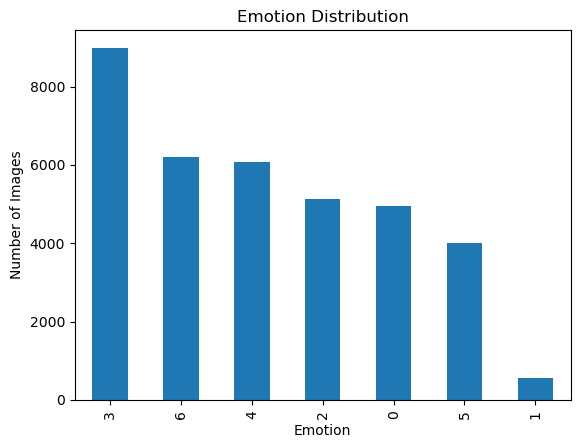

In [3]:
# understand dataset info
emotion_count = dataset["emotion"].value_counts()
print(emotion_count)

emotion_count.plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

In [4]:
# check missing value
print(dataset.isnull().sum()) 

emotion    0
pixels     0
Usage      0
dtype: int64


In [5]:
# check usage column
print(dataset["Usage"].value_counts())

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


In [6]:
# Step 2: Convert pixels to images
X = []

for pixels in dataset["pixels"]:

    img = np.array(pixels.split(), dtype=np.float32)
    img = img.reshape(48, 48)

    X.append(img)

X = np.array(X)

print("Before normalization:", X.shape)
print("Pixel range:", X.min(), X.max())

Before normalization: (35887, 48, 48)
Pixel range: 0.0 255.0


In [7]:
# Step 3: Normalize pixel values
X = X / 255.0

print("After normalization:")
print("Min:", X.min())
print("Max:", X.max())

After normalization:
Min: 0.0
Max: 1.0


In [8]:
# step 5 add channel dimension
# (number, height, width, channel)
# number = -1, so it will more dynamic, eg 35887 direct will be, no need write manually 
X = X.reshape(-1,48,48,1)           # channel 1 = grayscale
print(X)

[[[[0.27450982]
   [0.3137255 ]
   [0.32156864]
   ...
   [0.20392157]
   [0.16862746]
   [0.16078432]]

  [[0.25490198]
   [0.23921569]
   [0.22745098]
   ...
   [0.21960784]
   [0.20392157]
   [0.17254902]]

  [[0.19607843]
   [0.16862746]
   [0.21176471]
   ...
   [0.19215687]
   [0.21960784]
   [0.18431373]]

  ...

  [[0.35686275]
   [0.25490198]
   [0.16470589]
   ...
   [0.28235295]
   [0.21960784]
   [0.16862746]]

  [[0.3019608 ]
   [0.32156864]
   [0.30980393]
   ...
   [0.4117647 ]
   [0.27450982]
   [0.18039216]]

  [[0.3019608 ]
   [0.28235295]
   [0.32941177]
   ...
   [0.41568628]
   [0.42745098]
   [0.32156864]]]


 [[[0.5921569 ]
   [0.5882353 ]
   [0.5764706 ]
   ...
   [0.5058824 ]
   [0.54901963]
   [0.47058824]]

  [[0.5921569 ]
   [0.58431375]
   [0.58431375]
   ...
   [0.47843137]
   [0.5529412 ]
   [0.5372549 ]]

  [[0.5921569 ]
   [0.5921569 ]
   [0.6117647 ]
   ...
   [0.42745098]
   [0.48235294]
   [0.57254905]]

  ...

  [[0.7372549 ]
   [0.7372549 ]
   [0.4

In [9]:
# step 5: label encoding
# X = input feature (Image(), Y = target label (emotions)
y = to_categorical(dataset["emotion"], num_classes=7)

In [10]:
print("y shape:",y.shape)

y shape: (35887, 7)


In [11]:
# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          # 20% will use for test data
    random_state=42,        # seed = 42 will have higher accuracy 
    stratify=dataset["emotion"]
)

print(X_train.shape)
print(X_test.shape)

(28709, 48, 48, 1)
(7178, 48, 48, 1)


In [12]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (28709, 48, 48, 1)
Testing data: (7178, 48, 48, 1)


In [13]:
# Step 7: Save preprocessed data
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)